# Hilbert-Geometry Diagnostics
## Version 1: CICIoT2023 | 528 Training (Balanced) | Batch Size 64 | 10 Epochs | LR 0.01 | Seed 42 | Target (y) = "label_family" | Data Reupload = 2

## Setup

In [1]:
import pennylane as qp
from pennylane import numpy as np
import torch
import torch.nn as nn

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import json
from pathlib import Path
import time

In [2]:
from scripts.constants import DEFAULT_CF, DEFAULT_NOISE_RATE, ZERO_DAY
from scripts.data import (
    balanced_sample,
    class_balance_table,
    load_split,
    plot_class_balance_pie,
    plot_class_balance_bars,
    stratified_head,
)
from scripts.circuit import build_forward_circuit, create_quantum_device, initialize_weights
from scripts.conformal import calibrate_threshold
from scripts.prototypes import PrototypeBank, compute_prototypes
from scripts.loss import maqt_loss, gradient_variance
from scripts.quantum_metrics import fidelity, trace_distance
from scripts.logging import write_history_log
from scripts.inference import estimate_lipschitz, predict_batch
from scripts.utils import expectations_to_tensor, get_torch_device, to_np_x, to_torch_x

In [3]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available?: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA device name: {torch.cuda.get_device_name(0)}")
    print(f"Current CUDA device index: {torch.cuda.current_device()}")

PyTorch version: 2.12.1+cu126
CUDA available?: True
CUDA device name: NVIDIA GeForce GTX 1060
Current CUDA device index: 0


## Load Dataset: CICIoT2023

In [4]:
data_path = "data/CICIoT2023/quantum"
target_col = "label_family"

In [5]:
df = pd.read_parquet(f"{data_path}/q8_train.parquet")
df

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [6]:
print(df["label_multiclass"].unique())
print()
print(df["label_family"].unique())

<ArrowStringArray>
[       'DDoS-RSTFINFlood',           'BenignTraffic',
         'DDoS-ICMP_Flood',          'DDoS-TCP_Flood',
 'DDoS-SynonymousIP_Flood',          'DDoS-SlowLoris',
       'DDoS-PSHACK_Flood',           'DoS-TCP_Flood',
          'DDoS-UDP_Flood',           'DoS-UDP_Flood',
          'DoS-HTTP_Flood',          'DDoS-SYN_Flood',
           'DoS-SYN_Flood',        'MITM-ArpSpoofing',
    'DictionaryBruteForce',            'DNS_Spoofing',
  'DDoS-UDP_Fragmentation',          'Recon-PortScan',
       'VulnerabilityScan',                     'XSS',
         'DDoS-HTTP_Flood', 'DDoS-ICMP_Fragmentation',
  'DDoS-ACK_Fragmentation',     'Recon-HostDiscovery',
            'Recon-OSScan',        'BrowserHijacking',
         'Recon-PingSweep',            'SqlInjection',
        'Backdoor_Malware',        'CommandInjection',
        'Uploading_Attack']
Length: 31, dtype: str

<ArrowStringArray>
[                       'ddos',                      'benign',
                      

In [7]:
# check rows if NaN dropped
df[df[target_col].notna()].copy()

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.032581,0.003637,0.125064,0.017957,1.419705e-01,1.057962,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
1,2.204835,0.378237,1.097552,1.699442,6.532626e-01,1.142228,0.322069,0.374114,BenignTraffic,0,benign
2,0.000000,0.000000,0.000000,0.000000,5.621659e-16,0.944141,0.000000,1.048536,DDoS-ICMP_Flood,1,ddos
3,0.000000,0.000071,0.298669,0.679082,1.579194e-01,1.075915,0.178744,3.141593,DDoS-TCP_Flood,1,ddos
4,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos
...,...,...,...,...,...,...,...,...,...,...,...
132161,0.000000,0.017165,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132162,0.009243,0.000000,0.126688,0.033338,1.422353e-01,1.058106,0.178744,0.362070,DDoS-RSTFINFlood,1,ddos
132163,0.000000,0.092489,0.085190,0.000000,9.831928e-02,1.022967,0.123910,1.238534,DDoS-UDP_Flood,1,ddos
132164,0.009310,0.000000,0.122890,0.000000,1.419705e-01,1.057771,0.178744,3.141593,DDoS-RSTFINFlood,1,ddos


In [8]:
# get labels
class_names = sorted(df[target_col].dropna().unique())
class_names

['backdoor_malware_ransomware',
 'benign',
 'bruteforce_password',
 'ddos',
 'dos',
 'recon',
 'spoofing_mitm',
 'web_injection']

In [9]:
# load all data
X_train_full, y_train_full = load_split(data_path, "q8_train", target_col, class_names)
X_cal_full, y_cal_full = load_split(data_path, "q8_calibration", target_col, class_names)
X_test_full, y_test_full = load_split(data_path, "q8_test", target_col, class_names)
X_val_full, y_val_full = load_split(data_path, "q8_val", target_col, class_names)

In [10]:
# check shape
[X_train_full.shape, y_train_full.shape], [X_cal_full.shape, y_cal_full.shape], [X_test_full.shape, y_test_full.shape], [X_val_full.shape, y_val_full.shape]

([(132166, 8), (132166,)],
 [(18883, 8), (18883,)],
 [(18883, 8), (18883,)],
 [(18883, 8), (18883,)])

## EDA (Before Class-Balancing)

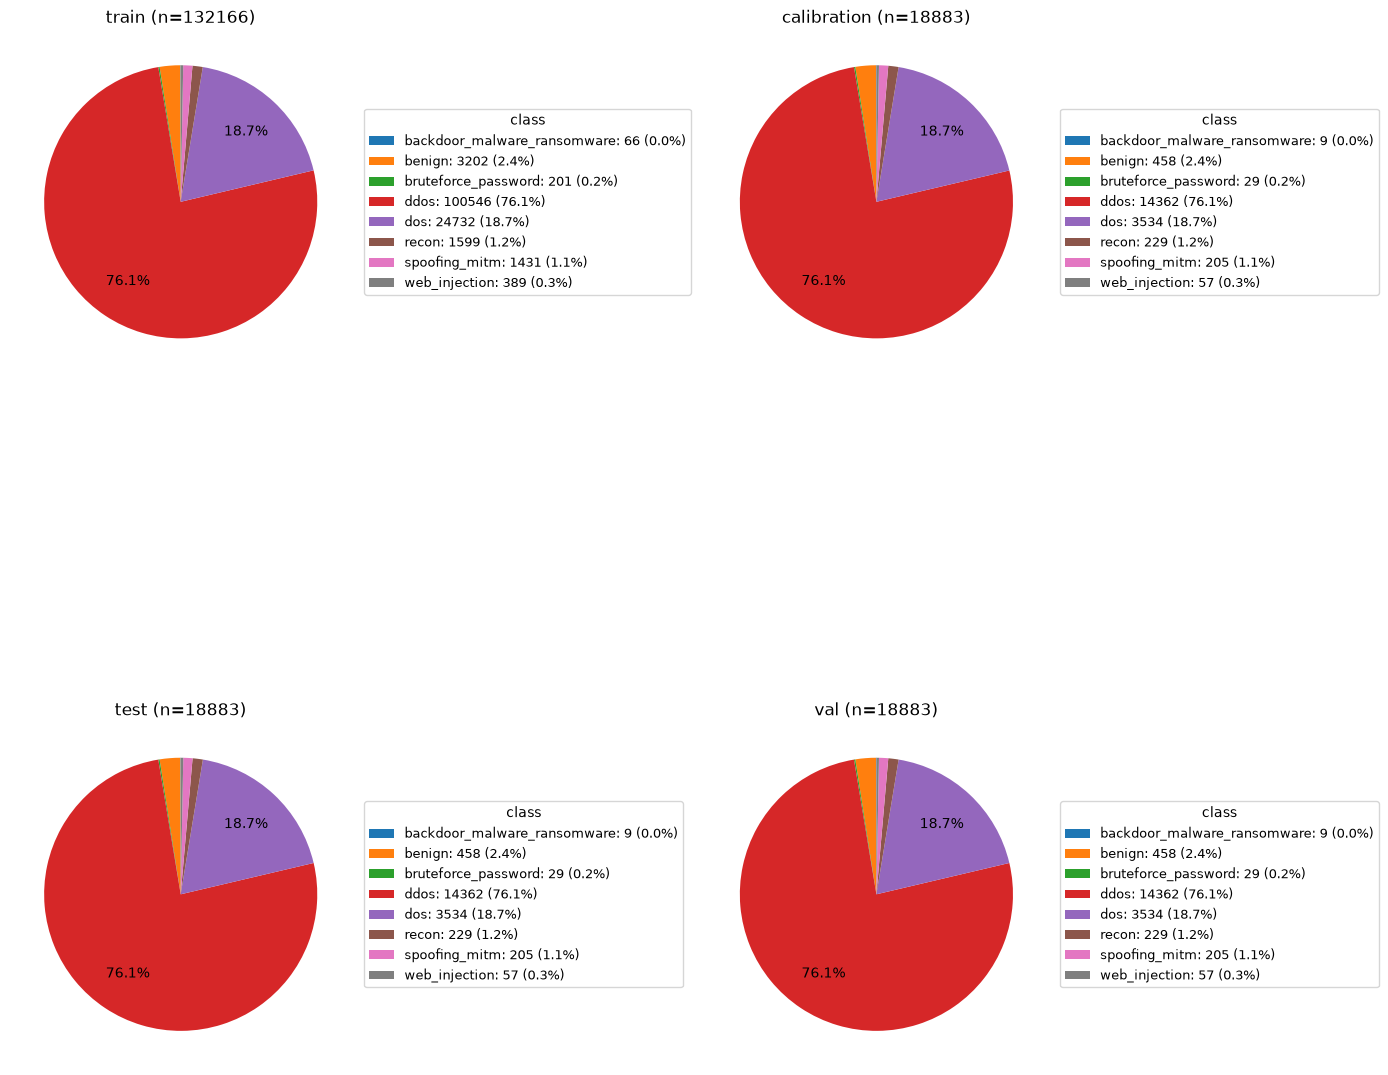

In [11]:
# pie chart
splits = {
    "train": y_train_full,
    "calibration": y_cal_full,
    "test": y_test_full,
    "val": y_val_full,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

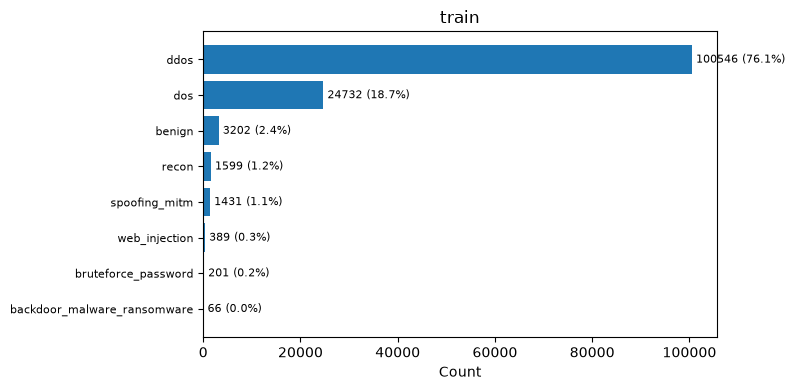

In [12]:
plot_class_balance_bars(y_train_full, class_names, title="train")
plt.show()

## Class Balancing, Data Subset

In [13]:
# use the smallest class size as the target count for undersampling
n_per_class = 66

# balance class on full data
X_train_balanced, y_train_balanced = balanced_sample(X_train_full, y_train_full, n_per_class=n_per_class, seed=42)
X_train_balanced.shape, y_train_balanced.shape

((528, 8), (528,))

In [14]:
# take subset
X_train, y_train = stratified_head(X_train_balanced, y_train_balanced, 1000, seed=42)
X_cal, y_cal = stratified_head(X_cal_full, y_cal_full, 150, seed=42)
X_test, y_test = stratified_head(X_test_full, y_test_full, 150, seed=42)
X_val, y_val = stratified_head(X_val_full, y_val_full, 150, seed=42)

In [15]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([(528, 8), (528,)],
 [(150, 8), (150,)],
 [(150, 8), (150,)],
 [(150, 8), (150,)])

## EDA (After Class-Balancing)

In [16]:
num_classes = len(class_names)
num_qubits = X_train.shape[1]

print(f"classes: {class_names}")
print(f"number of classes: {num_classes}")
print(f"number of qubits: {num_qubits}")

classes: ['backdoor_malware_ransomware', 'benign', 'bruteforce_password', 'ddos', 'dos', 'recon', 'spoofing_mitm', 'web_injection']
number of classes: 8
number of qubits: 8


In [17]:
# initialize devices
dev = qp.device("default.mixed", wires=num_qubits)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
# convert data type
X_train = to_torch_x(X_train)
y_train = to_torch_x(y_train).long()

In [19]:
# check shape
[X_train.shape, y_train.shape], [X_cal.shape, y_cal.shape], [X_test.shape, y_test.shape], [X_val.shape, y_val.shape]

([torch.Size([528, 8]), torch.Size([528])],
 [(150, 8), (150,)],
 [(150, 8), (150,)],
 [(150, 8), (150,)])

In [20]:
# table
splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
    "val": y_val,
}

for name, y in splits.items():
    table = class_balance_table(y, class_names)
    print(f"{name} (n={len(to_np_x(y))})")
    display(table)

train (n=528)


,class,count,pct
0,backdoor_malware_ransomware,66,12.5
1,benign,66,12.5
2,bruteforce_password,66,12.5
3,ddos,66,12.5
4,dos,66,12.5
5,recon,66,12.5
6,spoofing_mitm,66,12.5
7,web_injection,66,12.5


calibration (n=150)


,class,count,pct
0,backdoor_malware_ransomware,0,0.000000
1,benign,4,2.666667
2,bruteforce_password,0,0.000000
3,ddos,114,76.000000
4,dos,28,18.666667
5,recon,2,1.333333
6,spoofing_mitm,2,1.333333
7,web_injection,0,0.000000


test (n=150)


,class,count,pct
0,backdoor_malware_ransomware,0,0.000000
1,benign,4,2.666667
2,bruteforce_password,0,0.000000
3,ddos,114,76.000000
4,dos,28,18.666667
5,recon,2,1.333333
6,spoofing_mitm,2,1.333333
7,web_injection,0,0.000000


val (n=150)


,class,count,pct
0,backdoor_malware_ransomware,0,0.000000
1,benign,4,2.666667
2,bruteforce_password,0,0.000000
3,ddos,114,76.000000
4,dos,28,18.666667
5,recon,2,1.333333
6,spoofing_mitm,2,1.333333
7,web_injection,0,0.000000


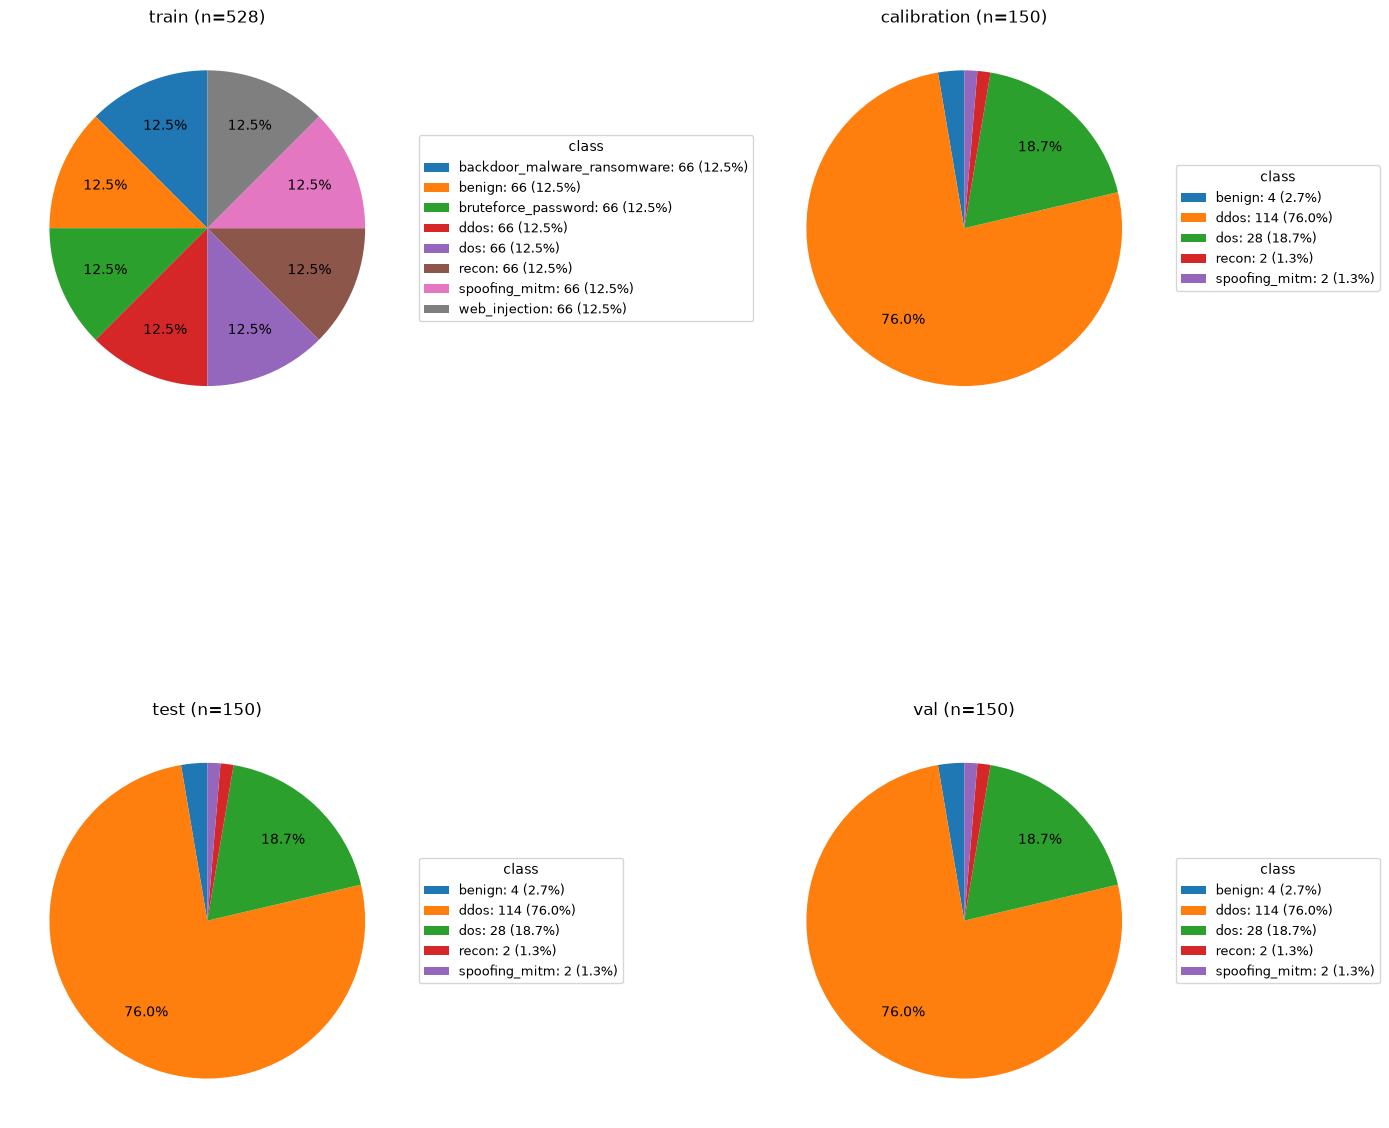

In [21]:
# pie chart
splits = {
    "train": y_train,
    "calibration": y_cal,
    "test": y_test,
    "val": y_val,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (name, y) in zip(axes.ravel(), splits.items()):
    plot_class_balance_pie(y, class_names, title=f"{name} (n={len(to_np_x(y))})", ax=ax)

plt.tight_layout()
plt.show()

## Quantum Circuit: Angle Encoding, Data Reuploading, and Adding Noise

$x\xrightarrow[\text{encode}]{\phi(x)}\ket{\psi(x)}\xrightarrow[\text{variational}]{U(\theta)}\ket{\Phi(x)}\xrightarrow{\Lambda_p}\rho(x)$
- $x$: classical data
- $\phi(x)$: `qp.AngleEmbedding()`
- $\ket{\psi(x)}$: quantum state after encoding
- $U(\theta)$: `qp.StronglyEntanglingLayers()`
- $\ket{\Phi(x)}$: quantum state after variational transform
- $\rho(x)=\Lambda_p(\ket{\Phi(x)}\bra{\Phi(x)})$: standard depolarization channel to model NISQ noise

In [22]:
num_layers = 2                  # reupload same classical data
noise_rate = DEFAULT_NOISE_RATE
device = get_torch_device()

In [23]:
# initialize device
dev = create_quantum_device(num_qubits)

# define circuit
forward_circuit = build_forward_circuit(dev, num_qubits, num_layers, noise_rate=noise_rate)

# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)

# define classifier head
classifier_head = nn.Linear(num_qubits, num_classes).to(device)

In [24]:
# initialize weights
theta = initialize_weights(num_layers, num_qubits, device)
theta.shape

torch.Size([2, 8, 3])

In [25]:
# DEBUG
theta

Parameter containing:
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], device='cuda:0', requires_grad=True)

## Training

$$
L = L_{CE} + \lambda_1 L_{intra} + \lambda_2 L_{inter}
$$

Minimizing:
- $L_{CE}$ adjusts $\theta$ for better class predictions.
- $L_{intra}$ pulls each sample toward its class prototype
- $L_{inter}$ pushs different-class prototypes apart (maximize trace distance)

In [26]:
lambda1 = 0.5
lambda2 = 0.3
epochs = 10
batch_size = 64
lr = 0.01
barren_plateau_var = 1e-6
COMPUTE_GRAD_VAR = True

In [27]:
# define loss function
ce_loss_fn = nn.CrossEntropyLoss()

# define optimizer
optimizer = torch.optim.Adam(list([theta]) + list(classifier_head.parameters()), lr=lr)

# define prototype bank
prototype_bank = PrototypeBank(range(num_classes))

In [28]:
history = {
    "loss": [], "l_ce": [], "l_intra": [], "l_inter": [],
    "grad_var": [], "barren_plateau": [],
    "epoch_sec": [],
}

num_batches = (len(X_train) + batch_size - 1) // batch_size
print(f"training: {len(X_train)} samples, {num_batches} batches/epoch, {epochs} epochs")

train_t0 = time.perf_counter()

for epoch in range(epochs):
    epoch_t0 = time.perf_counter()
    prototype_bank.reset()
    perm = torch.randperm(len(X_train), device=device)

    epoch_grad_vars = []
    epoch_loss, epoch_ce, epoch_intra, epoch_inter = [], [], [], []

    for batch_idx, start in enumerate(range(0, len(perm), batch_size)):
        batch_t0 = time.perf_counter()

        idx = perm[start : start + batch_size]
        X_batch, y_batch = X_train[idx], y_train[idx]

        for x, label in zip(X_batch, y_batch):
            _, rho_x = forward_circuit(x, theta)
            prototype_bank.update(int(label.item()), rho_x)
        batch_prototypes = prototype_bank.means()

        loss, L_CE, L_intra, L_inter = maqt_loss(
            theta, classifier_head, ce_loss_fn,
            X_batch, y_batch, batch_prototypes, forward_circuit,
            lambda1=lambda1, lambda2=lambda2, device=device,
        )

        optimizer.zero_grad()
        loss.backward()

        if COMPUTE_GRAD_VAR:
            gvar, _ = gradient_variance(
                theta, classifier_head, ce_loss_fn,
                X_batch, y_batch, batch_prototypes, forward_circuit,
                lambda1=lambda1, lambda2=lambda2, device=device,
            )
            epoch_grad_vars.append(gvar)

        optimizer.step()

        epoch_loss.append(float(loss.item()))
        epoch_ce.append(float(L_CE.item()))
        epoch_intra.append(float(L_intra.item()))
        epoch_inter.append(float(L_inter.item()))

        batch_sec = time.perf_counter() - batch_t0
        print(
            f"epoch {epoch + 1} batch {batch_idx}/{num_batches - 1} | {batch_sec:.1f}s",
            flush=True,
        )

    mean_gvar = float(np.mean(epoch_grad_vars)) if epoch_grad_vars else 0.0
    plateau = mean_gvar < barren_plateau_var
    epoch_sec = time.perf_counter() - epoch_t0

    history["loss"].append(float(np.mean(epoch_loss)))
    history["l_ce"].append(float(np.mean(epoch_ce)))
    history["l_intra"].append(float(np.mean(epoch_intra)))
    history["l_inter"].append(float(np.mean(epoch_inter)))
    history["grad_var"].append(mean_gvar)
    history["barren_plateau"].append(plateau)
    history["epoch_sec"].append(epoch_sec)

    # log intra-class and inter-class fidelity gaps (H1 diagnostics)
    protos = prototype_bank.means()
    classes = sorted(protos)
    inter_fids = []
    for i, c in enumerate(classes):
        for c2 in classes[i + 1:]:
            f = fidelity(protos[c], protos[c2])
            inter_fids.append(float(f.real.item() if torch.is_tensor(f) else f))
    mean_intra_fid_proxy = 1.0 - history["l_intra"][-1]
    mean_inter_fid = float(np.mean(inter_fids)) if inter_fids else float("nan")
    fidelity_gap_proxy = mean_intra_fid_proxy - mean_inter_fid
    history.setdefault("mean_intra_fid_proxy", []).append(mean_intra_fid_proxy)
    history.setdefault("mean_inter_fid", []).append(mean_inter_fid)
    history.setdefault("fidelity_gap_proxy", []).append(fidelity_gap_proxy)
    
    print(
        f"epoch {epoch + 1:02d}/{epochs} | "
        f"loss={history['loss'][-1]:.4f} | "
        f"l_ce={history['l_ce'][-1]:.4f} | "
        f"l_intra={history['l_intra'][-1]:.4f} | "
        f"l_inter={history['l_inter'][-1]:.4f} | "
        f"gap≈{fidelity_gap_proxy:.4f} | "
        f"grad_var={mean_gvar:.2e} | barren_plateau={plateau} | "
        f"time={epoch_sec:.1f}s"
    )

total_sec = time.perf_counter() - train_t0
print(f"training done in {total_sec/60:.1f} min ({total_sec:.1f}s)")

theta_star = theta
prototypes = compute_prototypes(
    theta_star, X_train, y_train, range(num_classes),
    forward_circuit=forward_circuit, device=device,
)

training: 528 samples, 9 batches/epoch, 10 epochs
epoch 1 batch 0/8 | 35.6s
epoch 1 batch 1/8 | 35.5s
epoch 1 batch 2/8 | 35.6s
epoch 1 batch 3/8 | 36.0s
epoch 1 batch 4/8 | 35.9s
epoch 1 batch 5/8 | 35.8s
epoch 1 batch 6/8 | 36.1s
epoch 1 batch 7/8 | 35.9s
epoch 1 batch 8/8 | 9.8s
epoch 01/10 | loss=2.2093 | l_ce=2.1024 | l_intra=0.6115 | l_inter=-0.6627 | gap≈-0.0999 | grad_var=9.22e-05 | barren_plateau=False | time=296.2s
epoch 2 batch 0/8 | 35.3s
epoch 2 batch 1/8 | 35.7s
epoch 2 batch 2/8 | 35.6s
epoch 2 batch 3/8 | 35.7s
epoch 2 batch 4/8 | 35.8s
epoch 2 batch 5/8 | 35.8s
epoch 2 batch 6/8 | 35.7s
epoch 2 batch 7/8 | 35.7s
epoch 2 batch 8/8 | 9.7s
epoch 02/10 | loss=2.1458 | l_ce=2.0326 | l_intra=0.6161 | l_inter=-0.6498 | gap≈-0.1086 | grad_var=1.03e-04 | barren_plateau=False | time=295.0s
epoch 3 batch 0/8 | 35.4s
epoch 3 batch 1/8 | 35.9s
epoch 3 batch 2/8 | 35.6s
epoch 3 batch 3/8 | 35.7s
epoch 3 batch 4/8 | 36.0s
epoch 3 batch 5/8 | 36.0s
epoch 3 batch 6/8 | 36.2s
epoch 3 ba

In [29]:
# write log (temporarily after training)
log_path = write_history_log(
    history,
    notebook="Hilbert-geometry-diagnostics_v1.ipynb",
    extra={
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
    },
    log_dir="logs"
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/qsentinel/quantum-sentinel/logs/Hilbert-geometry-diagnostics_v1.log


In [30]:
# DEBUG
theta_star

Parameter containing:
tensor([[[ 0.0000,  0.3153,  0.0000],
         [ 0.0000, -0.0683,  0.0000],
         [ 0.0000,  0.0713,  0.0000],
         [ 0.0000, -0.3022,  0.0000],
         [ 0.0000, -0.0706,  0.0000],
         [ 0.0000, -0.4964,  0.0000],
         [ 0.0000, -0.0085,  0.0000],
         [ 0.0000,  0.6833,  0.0000]],

        [[ 0.0000, -0.3787,  0.0000],
         [ 0.0000, -0.1468,  0.0000],
         [ 0.0000,  0.1776,  0.0000],
         [ 0.0000, -0.3492,  0.0000],
         [ 0.0000,  0.0153,  0.0000],
         [ 0.0000, -0.9171,  0.0000],
         [ 0.0000, -0.0180,  0.0000],
         [ 0.0000,  0.7750,  0.0000]]], device='cuda:0', requires_grad=True)

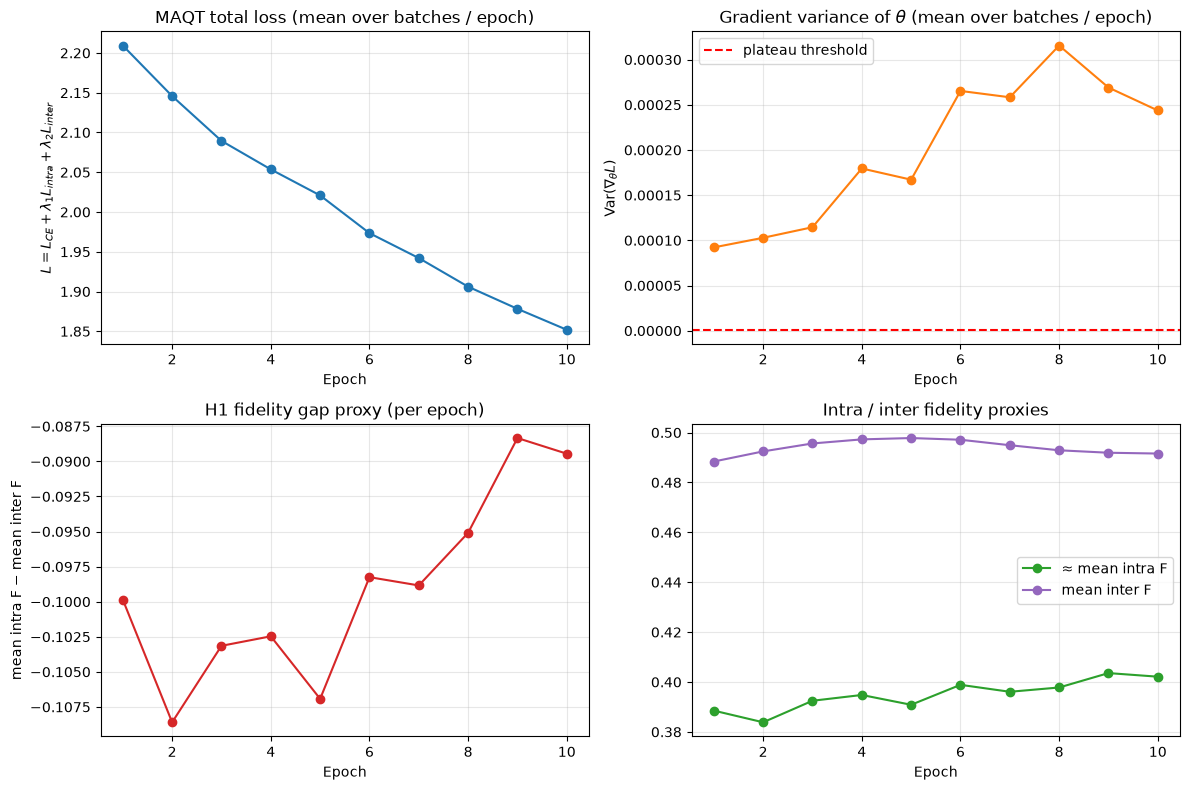

In [31]:
# plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(range(1, epochs + 1), history["loss"], marker="o")
axes[0, 0].set_title("MAQT total loss (mean over batches / epoch)")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel(r"$L = L_{CE} + \lambda_1 L_{intra} + \lambda_2 L_{inter}$")
axes[0, 0].grid(True, alpha=0.3)


axes[0, 1].plot(range(1, epochs + 1), history["grad_var"], marker="o", color="tab:orange")
axes[0, 1].axhline(barren_plateau_var, color="red", linestyle="--", label="plateau threshold")
axes[0, 1].set_title("Gradient variance of $\\theta$ (mean over batches / epoch)")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Var($\\nabla_\\theta L$)")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

epochs_x = range(1, len(history["fidelity_gap_proxy"]) + 1)

axes[1, 0].plot(epochs_x, history["fidelity_gap_proxy"], marker="o", color="tab:red")
axes[1, 0].set_title("H1 fidelity gap proxy (per epoch)")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("mean intra F − mean inter F")
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(epochs_x, history["mean_intra_fid_proxy"], marker="o", label="≈ mean intra F", color="tab:green")
axes[1, 1].plot(epochs_x, history["mean_inter_fid"], marker="o", label="mean inter F", color="tab:purple")
axes[1, 1].set_title("Intra / inter fidelity proxies")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## H1 Diagnostics

### Loss Functions
- **Intra-class loss** (infidelity to own prototype):
  $$
  L_{\mathrm{intra}}
  = \frac{1}{|\mathcal{C}|}
    \sum_{c \in \mathcal{C}}
    \mathbb{E}_{x \sim c}
    \big[1 - F(\rho(x), \rho_c)\big]
  $$
- **Inter-class loss** (negative mean prototype separation):
  $$
  L_{\mathrm{inter}}
  = - \frac{1}{|\mathcal{P}|}
    \sum_{(c,c') \in \mathcal{P}}
    D_{\mathrm{tr}}(\rho_c, \rho_{c'})
  $$
  where $\mathcal{P}$ is the set of unordered class pairs and $D_{\mathrm{tr}}$ is trace distance.

### Fidelity Gap
$$
\Delta F = \underbrace{\overline{F}_{\mathrm{intra}}}_{\mathrm{mean}_{c}\,(\mathrm{mean}_{x \in c} F(\rho(x), \rho_c))} - \underbrace{\overline{F}_{\mathrm{inter}}}_{\mathrm{mean}_{(c,c')} F(\rho_c,\rho_{c'})}
$$

where:

- $\overline{F}_{\mathrm{intra}} \approx 1 - L_{\mathrm{intra}}$ (proxy from the loss)
- $\overline{F}_{\mathrm{intra}} = \mathrm{mean\_intra\_fid} = \mathrm{mean}_{c}\,(\mathrm{mean}_{x \in c} F(\rho(x), \rho_c))$ (direct definition / H1 measurement)
    - $\mathrm{mean\_intra\_fid}_c = \mathrm{mean}_{x \in c} F(\rho(x), \rho_c)$ (per-class intra fidelity)
- $\overline{F}_{\mathrm{inter}} = \mathrm{mean\_inter\_fid} = \mathrm{mean}_{(c,c')} F(\rho_c,\rho_{c'})$
  (explicit fidelity; not from $L_{\mathrm{inter}}$)

### Ideal Trends
| Goal | Geometry | $L$ | Fidelity |
|---|---|---|---|
| Same class tighter | closer to $\rho_c$ | $L_{\mathrm{intra}} \downarrow$ | $F(\rho(x),\rho_c) \uparrow$ |
| Different classes farther | prototypes separate | $L_{\mathrm{inter}} \downarrow$ (more negative; $D_{\mathrm{tr}} \uparrow$) | $F(\rho_c,\rho_{c'}) \downarrow$ |
| Better Hilbert margin | - | - | $\Delta F \uparrow$ |

In [32]:
@torch.no_grad()
def hilbert_geometry_diagnostics(theta, X, y, prototypes, forward_circuit, class_names=None, device=None, max_per_class=None, seed=42):
    """
    Compute H1 (intra/inter fidelity gaps) in Hilbert space.
    """
    y_np = to_np_x(y).astype(int)
    rng = np.random.default_rng(seed)

    per_class = {}
    mean_intra_fid_per_class = []

    for c in sorted(prototypes):
        idx = np.where(y_np == c)[0]
        if len(idx) == 0:
            continue
        if max_per_class is not None and len(idx) > max_per_class:
            idx = rng.choice(idx, size=max_per_class, replace=False)

        fids = []
        for i in idx:
            _, rho_x = forward_circuit(to_torch_x(X[i], device=device), theta)
            f = fidelity(rho_x, prototypes[c])
            fids.append(float(f.real.item() if torch.is_tensor(f) else f))

        mean_intra_fid_c = float(np.mean(fids))
        name = class_names[c] if class_names is not None else str(c)
        per_class[name] = {
            "n": int(len(fids)),
            "mean_intra_fid_c": mean_intra_fid_c,
            "mean_intra_infidelity_c": 1.0 - mean_intra_fid_c,  # same spirit as L_intra
        }
        mean_intra_fid_per_class.append(mean_intra_fid_c)

    # inter-class fidelity + trace distance between prototypes
    classes = sorted(prototypes)
    pair_inter_fids, pair_inter_tds = [], []
    pair_rows = []
    for i, c in enumerate(classes):
        for c2 in classes[i + 1 :]:
            f = fidelity(prototypes[c], prototypes[c2])
            td = trace_distance(prototypes[c], prototypes[c2])
            f = float(f.real.item() if torch.is_tensor(f) else f)
            td = float(td.real.item() if torch.is_tensor(td) else td)
            pair_inter_fids.append(f)
            pair_inter_tds.append(td)
            n1 = class_names[c] if class_names is not None else str(c)
            n2 = class_names[c2] if class_names is not None else str(c2)
            pair_rows.append({"pair": f"{n1}↔{n2}", "pair_inter_fid": f, "pair_trace_distance": td})

    mean_intra_fid = float(np.mean(mean_intra_fid_per_class)) if mean_intra_fid_per_class else float("nan")
    mean_inter_fid = float(np.mean(pair_inter_fids)) if pair_inter_fids else float("nan")
    fidelity_gap = mean_intra_fid - mean_inter_fid

    report = {
        "mean_intra_fid": mean_intra_fid,
        "mean_inter_fid": mean_inter_fid,
        "fidelity_gap": fidelity_gap,  # H1 headline metric
        "mean_inter_trace_distance": float(np.mean(pair_inter_tds)) if pair_inter_tds else float("nan"),
        "per_class": per_class,
        "pairs": pair_rows,
    }
    return report

In [33]:
def print_h1_report(report):
    """
    Helper print function.
    """
    print("=== H1 Hilbert geometry (fidelity gaps) ===")
    print(f"mean intra-class fidelity : {report['mean_intra_fid']:.4f}")
    print(f"mean inter-class fidelity : {report['mean_inter_fid']:.4f}")
    print(f"fidelity gap (intra-inter): {report['fidelity_gap']:.4f}  ← want ↑")
    print(f"mean inter trace distance : {report['mean_inter_trace_distance']:.4f}  ← want ↑")
    print("\nper-class intra fidelity:")
    for name, row in report["per_class"].items():
        print(f"  {name:28s} n={row['n']:4d}  F={row['mean_intra_fid_c']:.4f}")

In [34]:
h1 = hilbert_geometry_diagnostics(
    theta_star, X_train, y_train, prototypes, forward_circuit,
    class_names=class_names, device=device, max_per_class=50,
)
print_h1_report(h1)

=== H1 Hilbert geometry (fidelity gaps) ===
mean intra-class fidelity : 0.3919
mean inter-class fidelity : 0.4917
fidelity gap (intra-inter): -0.0998  ← want ↑
mean inter trace distance : 0.6161  ← want ↑

per-class intra fidelity:
  backdoor_malware_ransomware  n=  50  F=0.3756
  benign                       n=  50  F=0.3760
  bruteforce_password          n=  50  F=0.3410
  ddos                         n=  50  F=0.5862
  dos                          n=  50  F=0.5266
  recon                        n=  50  F=0.3147
  spoofing_mitm                n=  50  F=0.3027
  web_injection                n=  50  F=0.3123


In [35]:
# within-class (intra)
display(pd.DataFrame(h1["per_class"]).T)
display(pd.DataFrame(h1["pairs"]).sort_values("pair_inter_fid", ascending=False))

,n,mean_intra_fid_c,mean_intra_infidelity_c
backdoor_malware_ransomware,50.0,0.375600,0.624400
benign,50.0,0.376012,0.623988
bruteforce_password,50.0,0.341043,0.658957
ddos,50.0,0.586219,0.413781
dos,50.0,0.526643,0.473357
recon,50.0,0.314717,0.685283
spoofing_mitm,50.0,0.302746,0.697254
web_injection,50.0,0.312285,0.687715


,pair,pair_inter_fid,pair_trace_distance
18,ddos↔dos,0.903286,0.201290
17,bruteforce_password↔web_injection,0.881123,0.273172
6,backdoor_malware_ransomware↔web_injection,0.854075,0.329326
1,backdoor_malware_ransomware↔bruteforce_password,0.846005,0.334166
15,bruteforce_password↔recon,0.823577,0.326343
26,recon↔web_injection,0.813299,0.328837
11,benign↔spoofing_mitm,0.790639,0.371902
4,backdoor_malware_ransomware↔recon,0.776752,0.372532
7,benign↔bruteforce_password,0.704138,0.491567
27,spoofing_mitm↔web_injection,0.670282,0.515121


## Algo 2: Conformal Zero-Day Threshold Calibration (CQ-ZDR)

Nonconformity score: $s_i = 1 - \max_c F(\rho(x_i), \rho_c)$.

Split-conformal threshold: $q = s_{(k)}$ with $k = \lceil (1 - \alpha)(n + 1) \rceil$.

In [36]:
alpha = 0.05
q, scores_sorted = calibrate_threshold(theta_star, X_cal, prototypes, forward_circuit, alpha=alpha, device=device)
print(f"conformal threshold q = {q:.4f} (alpha={alpha}, n_cal={len(X_cal)})")

conformal threshold q = 0.6262 (alpha=0.05, n_cal=150)


## Algo 3: Unified Inference with Disentangled Rejection

At test time, one pass produces either
- a class label with a certified robustness radius $\rightarrow$ `(label, certified_radius)`, or
- a zero-day flag $\rightarrow$ `(ZERO_DAY, 0)`.

In [37]:
# estimate Lipschitz constant
L_phi = estimate_lipschitz(X_train, theta_star, forward_circuit, n_probe=30, delta=0.05, device=device)
print(f"estimated L_phi = {L_phi:.4f}")

estimated L_phi = 2.8586


## Evaluation on Known Test Samples

known-sample accuracy (non-rejected): 0.782
rejection rate on test: 0.053
mean certified radius (accepted): 0.0082

classification report (accepted predictions only):
                             precision    recall  f1-score   support

backdoor_malware_ransomware       0.00      0.00      0.00         0
                     benign       0.50      0.67      0.57         3
        bruteforce_password       0.00      0.00      0.00         0
                       ddos       0.83      0.95      0.89       111
                        dos       0.38      0.12      0.18        25
                      recon       0.00      0.00      0.00         1
              spoofing_mitm       0.00      0.00      0.00         2
              web_injection       0.00      0.00      0.00         0

                   accuracy                           0.78       142
                  macro avg       0.21      0.22      0.21       142
               weighted avg       0.72      0.78      0.74       142



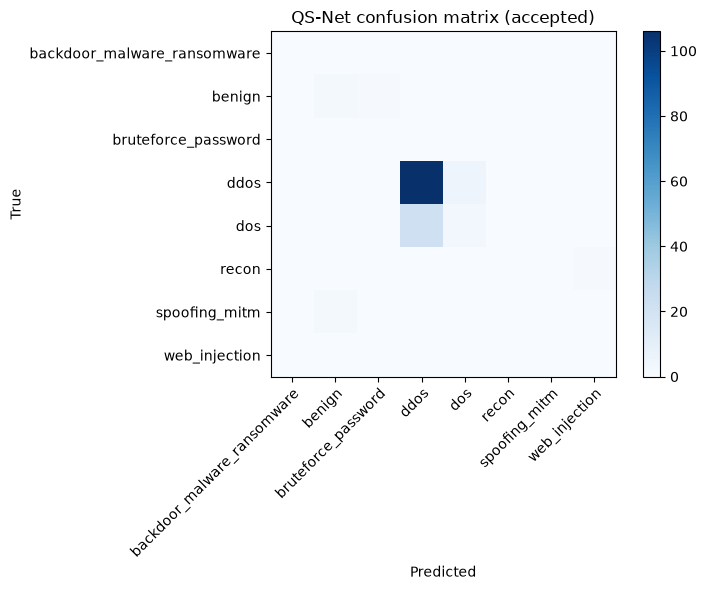

In [38]:
y_pred, radii, novelty_scores = predict_batch(
    X_test, theta_star, prototypes, q, forward_circuit, p=noise_rate, L_phi=L_phi, Cf=DEFAULT_CF, device=device,
)

known_mask = y_pred != ZERO_DAY
label_ids = list(range(num_classes))

known_acc = np.mean(y_pred[known_mask] == y_test[known_mask]) if known_mask.any() else 0.0
reject_rate = 1.0 - known_mask.mean()

print(f"known-sample accuracy (non-rejected): {known_acc:.3f}")
print(f"rejection rate on test: {reject_rate:.3f}")
print(f"mean certified radius (accepted): {radii[known_mask].mean():.4f}")

if known_mask.any():
    print("\nclassification report (accepted predictions only):")
    print(classification_report(
        y_test[known_mask], y_pred[known_mask],
        labels=label_ids, target_names=class_names, zero_division=0,
    ))

    cm = confusion_matrix(y_test[known_mask], y_pred[known_mask], labels=label_ids)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        xlabel="Predicted",
        ylabel="True",
        title="QS-Net confusion matrix (accepted)",
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    plt.tight_layout()
    plt.show()

In [39]:
# known-class accuracy using the trained CE readout, not fidelity inference or conformal rejection
with torch.no_grad():
    preds_ce = []
    for x in X_test:
        z, _ = forward_circuit(to_torch_x(x), theta_star)
        z = z if torch.is_tensor(z) else torch.stack(z)
        pred = classifier_head(z.float()).argmax().item()
        preds_ce.append(pred)

print("CE-head accuracy:", np.mean(np.array(preds_ce) == y_test))
print(classification_report(y_test, np.array(preds_ce), labels=label_ids, target_names=class_names, zero_division=0))

CE-head accuracy: 0.66
                             precision    recall  f1-score   support

backdoor_malware_ransomware       0.00      0.00      0.00         0
                     benign       1.00      0.25      0.40         4
        bruteforce_password       0.00      0.00      0.00         0
                       ddos       0.82      0.85      0.83       114
                        dos       1.00      0.04      0.07        28
                      recon       0.00      0.00      0.00         2
              spoofing_mitm       0.00      0.00      0.00         2
              web_injection       0.00      0.00      0.00         0

                   accuracy                           0.66       150
                  macro avg       0.35      0.14      0.16       150
               weighted avg       0.83      0.66      0.66       150



## Zero-Day Evaluation

In [40]:
df_zero = pd.read_parquet(f"{data_path}/q8_zeroday.parquet")
df_zero

,n_pkts_total,duration,pkt_size_max,pkt_size_std,pkt_size_mean,n_bytes_total,pkt_size_min,protocol,label_multiclass,label_binary,label_family
0,0.000000,0.341720,1.277049,0.000000,1.514452,2.111827,1.857477,1.238534,Mirai-udpplain,1,botnet_mirai
1,0.000000,0.306510,1.277049,1.002109,1.509367,2.106110,1.768736,1.238534,Mirai-udpplain,1,botnet_mirai
2,0.000000,0.000000,1.310114,0.000000,1.554586,2.141878,1.905572,3.141593,Mirai-greeth_flood,1,botnet_mirai
3,0.000000,0.000000,1.310114,0.000000,1.554586,2.141878,1.905572,3.141593,Mirai-greeth_flood,1,botnet_mirai
4,0.000000,0.000000,1.289592,1.503306,1.443681,2.066674,1.619096,3.141593,Mirai-greip_flood,1,botnet_mirai
...,...,...,...,...,...,...,...,...,...,...,...
10979,0.000000,0.000000,1.310114,0.025668,1.554562,2.141858,1.905229,3.141593,Mirai-greeth_flood,1,botnet_mirai
10980,0.003711,0.261604,1.277049,0.812117,1.510923,2.107637,1.812738,1.238534,Mirai-udpplain,1,botnet_mirai
10981,0.004044,0.002500,1.310114,0.973688,1.550295,2.137578,1.829819,3.141593,Mirai-greeth_flood,1,botnet_mirai
10982,0.007714,0.002847,1.310114,0.691768,1.553024,2.139929,1.872115,3.141593,Mirai-greeth_flood,1,botnet_mirai


In [41]:
df_zero["label_family"].unique()

<ArrowStringArray>
['botnet_mirai']
Length: 1, dtype: str

In [42]:
# load all data
feature_cols = [c for c in df_zero.columns if not c.startswith("label")]
X_zero_full = df_zero[feature_cols].values.astype(np.float32)
y_zero_full = df_zero["label_family"].values

# convert to np arrays
X_zero_full = np.asarray(X_zero_full, dtype=np.float32)
y_zero_full = np.asarray(y_zero_full).reshape(-1)

# take subset
X_zero, y_zero = stratified_head(X_zero_full, y_zero_full, 200, seed=42)

In [43]:
y_zero_pred, radii_zero, scores_zero = predict_batch(X_zero, theta_star, prototypes, q, forward_circuit,
                                                    p=DEFAULT_NOISE_RATE,
                                                    L_phi=L_phi,
                                                    Cf=DEFAULT_CF,
                                                    zero_day=ZERO_DAY,
                                                    device=device)

detected = y_zero_pred == ZERO_DAY
detection_rate = (detected).mean()

print(f"detected as ZERO_DAY: {detected.sum()} / {len(X_zero)} ({detection_rate:.1%})")
print(f"incorrectly accepted: {(~detected).sum()}")
print(f"mean novelty score: {scores_zero.mean():.4f} | threshold q: {q:.4f}")

if (~detected).any():
    for i in np.where(~detected)[0]:
        print(f"  accepted idx={i} true={y_zero[i]} pred={class_names[y_zero_pred[i]]} score={scores_zero[i]:.4f}")

detected as ZERO_DAY: 200 / 200 (100.0%)
incorrectly accepted: 0
mean novelty score: 0.9457 | threshold q: 0.6262


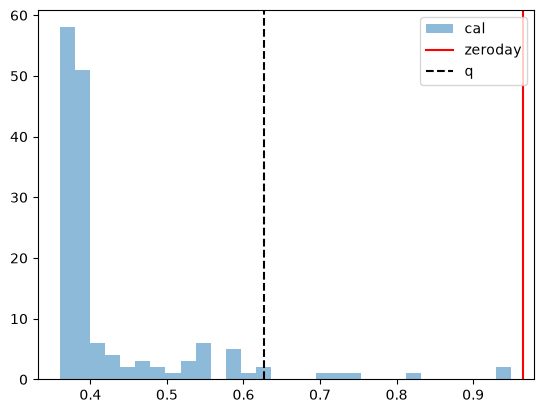

In [44]:
plt.hist(scores_sorted, bins=30, alpha=0.5, label="cal")
plt.axvline(scores_zero[0], color="r", label="zeroday")
plt.axvline(q, color="k", linestyle="--", label="q")
plt.legend(); plt.show()

## Logging

In [45]:
for k in history.keys():
    print(k)

loss
l_ce
l_intra
l_inter
grad_var
barren_plateau
epoch_sec
mean_intra_fid_proxy
mean_inter_fid
fidelity_gap_proxy


In [46]:
# write log (final)
log_path = write_history_log(
    history,
    notebook="Hilbert-geometry-diagnostics_v1.ipynb",
    extra={
        # algo 1: MAQT-based train
        "epochs": epochs,
        "batch_size": batch_size,
        "lr": lr,
        "lambda1": lambda1,
        "lambda2": lambda2,
        "noise_rate": noise_rate,
        "num_layers": num_layers,
        "num_qubits": num_qubits,
        "num_classes": num_classes,
        "n_train": len(X_train),
        "n_test": len(X_test),
        "barren_plateau_var": barren_plateau_var,
        "class_names": list(class_names),

        # algo 2: conformal
        "alpha": alpha,
        "q": float(q),
        "n_cal": len(X_cal),
        "cal_score_min": float(scores_sorted.min()),
        "cal_score_max": float(scores_sorted.max()),
        "cal_score_mean": float(scores_sorted.mean()),
        
        # algo 3: certified radius
        "L_phi": float(L_phi),
        "Cf": float(DEFAULT_CF) if "DEFAULT_CF" in dir() else float(Cf),

        # H1 diagnostics
        ## last-epoch training proxies
        "h1_last_mean_intra_fid_proxy": history["mean_intra_fid_proxy"][-1],  # ≈ 1 - L_intra
        "h1_last_mean_inter_fid": history["mean_inter_fid"][-1],              # F on epoch prototype_bank means
        "h1_last_fidelity_gap_proxy": history["fidelity_gap_proxy"][-1],      # proxy Delta F
        "train_total_sec": float(sum(history["epoch_sec"])),

        ## Delta F = mean_intra_fid - mean_inter_fid
        "h1_mean_intra_fid": h1["mean_intra_fid"],              # mean_c(mean_intra_fid_c)
        "h1_mean_inter_fid": h1["mean_inter_fid"],              # mean_{(c,c')} F(rho_c, rho_c')
        "h1_fidelity_gap": h1["fidelity_gap"],                  # Delta F
        "h1_mean_inter_trace_distance": h1["mean_inter_trace_distance"],  # mean_{(c,c')} D_tr
        "h1_per_class": h1["per_class"],                        # within-class: mean_intra_fid_c, mean_intra_infidelity_c
        "h1_pairs": h1["pairs"],                                # between-class: pair_inter_fid, pair_trace_distance  
    },
    log_dir="logs",
)
print(f"wrote {log_path.resolve()}")

wrote /home/lawun330/Desktop/qsentinel/quantum-sentinel/logs/Hilbert-geometry-diagnostics_v1.log


## References

- Importing PennyLane as qp: https://pennylane.ai/blog/2026/03/import-pennylane-as-qp-growing-beyond-just-qml
- Encoding data in angles: https://docs.pennylane.ai/en/stable/code/api/pennylane.AngleEmbedding.html
- Data reuploading: https://pennylane.ai/demos/tutorial_data_reuploading_classifier
- Strong entangling layers: https://docs.pennylane.ai/en/stable/code/api/pennylane.StronglyEntanglingLayers.html
- Standard depolarization: https://profmcruz.wordpress.com/wp-content/uploads/2017/08/quantum-computation-and-quantum-information-nielsen-chuang.pdf, p-378.
- Standard depolarization in PennyLane: https://docs.pennylane.ai/en/stable/code/api/pennylane.DepolarizingChannel.html